In [1]:
!pip install mlflow scikit-learn pandas numpy seaborn matplotlib cloudpickle requests

   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------------------  10.0/10.2 MB 78.4 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 59.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   ---------------------------------------- 3.0/3.0 MB 98.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 74.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 11.0/11.0 MB 113.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/829.5 kB ? eta -:--:--
   --------------------------------------- 829.5/829.5 kB 49.2 MB/s eta 0:00:00

   ----------------------------------------  0/26 [huey]
   ---- -----------------------------------  3/26 [sqlparse]
  Attempting uninstall: protobuf
   ---- -------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

print(red.shape)
print(white.shape)

(1599, 12)
(4898, 12)


In [4]:
red['is_red'] = 1
white['is_red'] = 0

data = pd.concat([red, white], axis=0)

# Remove spaces from column names
data.rename(columns=lambda x: x.replace(' ', '_'), inplace=True)

In [5]:
data.head()

data.info()

data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  is_red                6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 710.6 KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,is_red
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.246114
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,0.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,0.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,0.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [6]:
data.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
is_red                  0
dtype: int64

In [7]:
data = data.drop_duplicates()

In [8]:
data.dtypes

fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
is_red                    int64
dtype: object

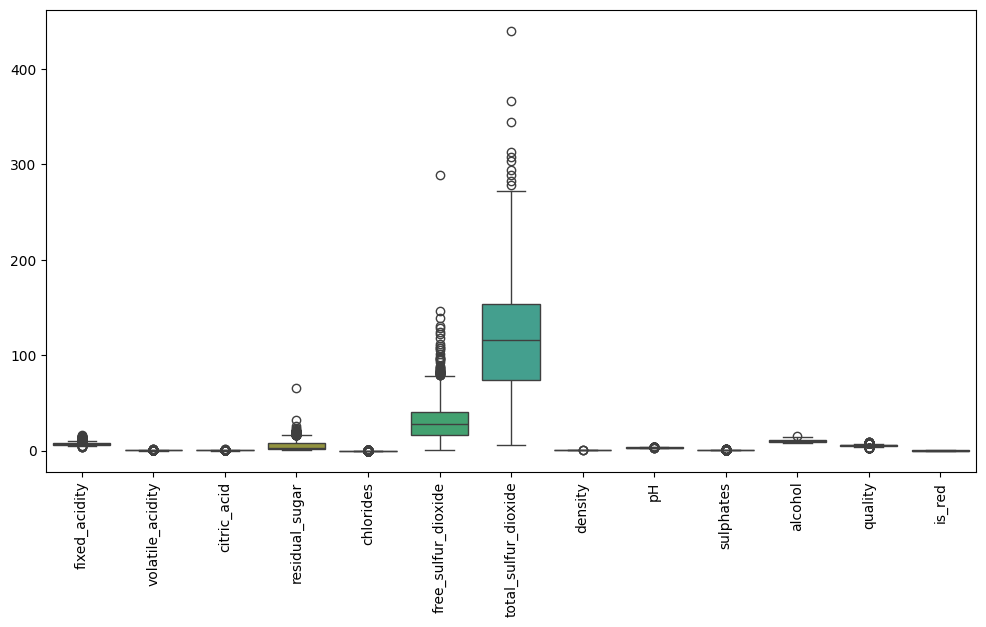

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

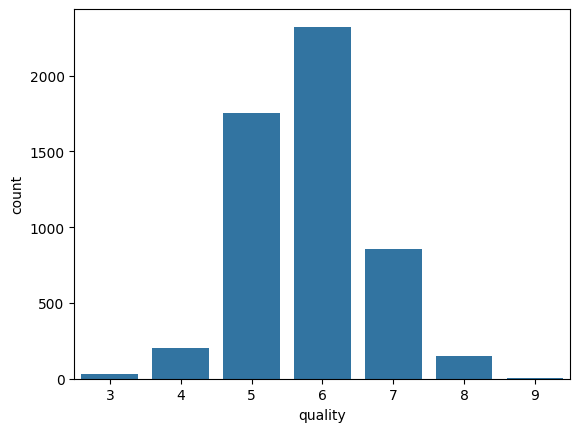

In [10]:
sns.countplot(x="quality", data=data)
plt.show()

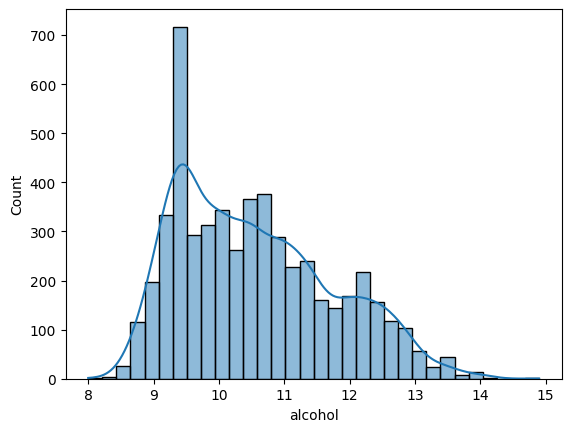

In [11]:
sns.histplot(data["alcohol"], kde=True)
plt.show()

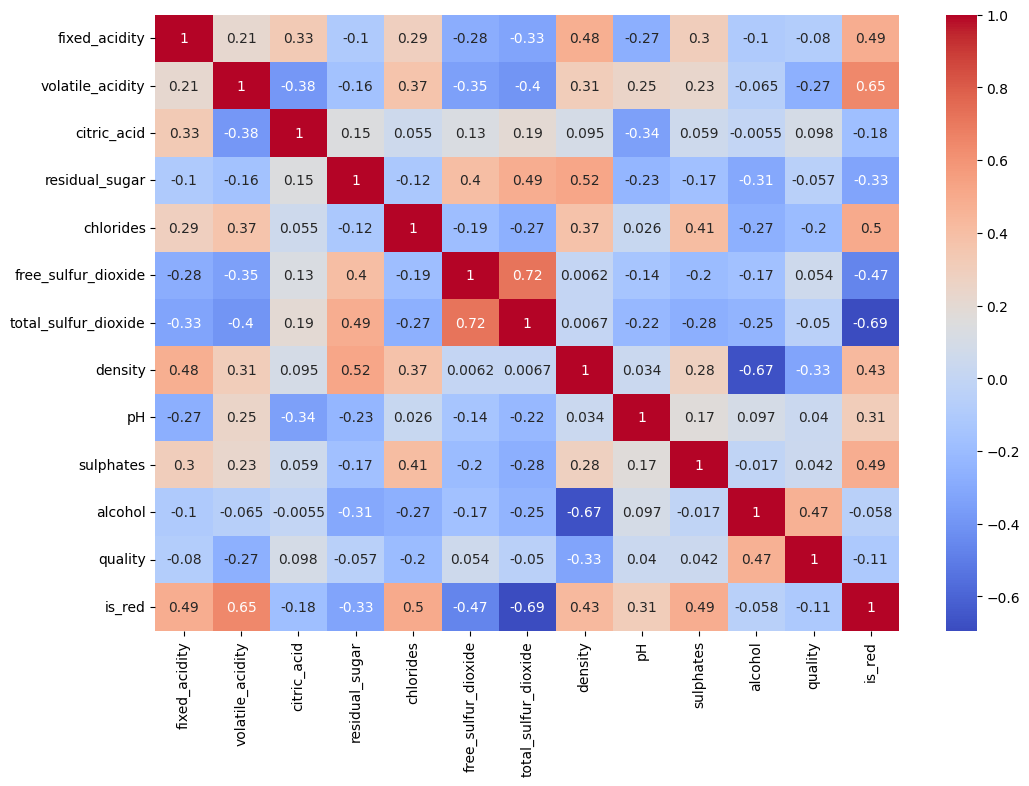

In [12]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

C:\Users\Aryan\AppData\Local\Temp\ipykernel_960\3323878950.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.quality, kde=False);


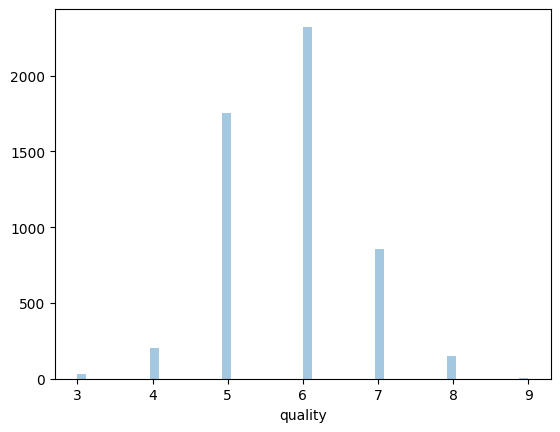

In [13]:
sns.distplot(data.quality, kde=False);

In [14]:
high_quality = (data.quality >= 7).astype(int)
data.quality = high_quality

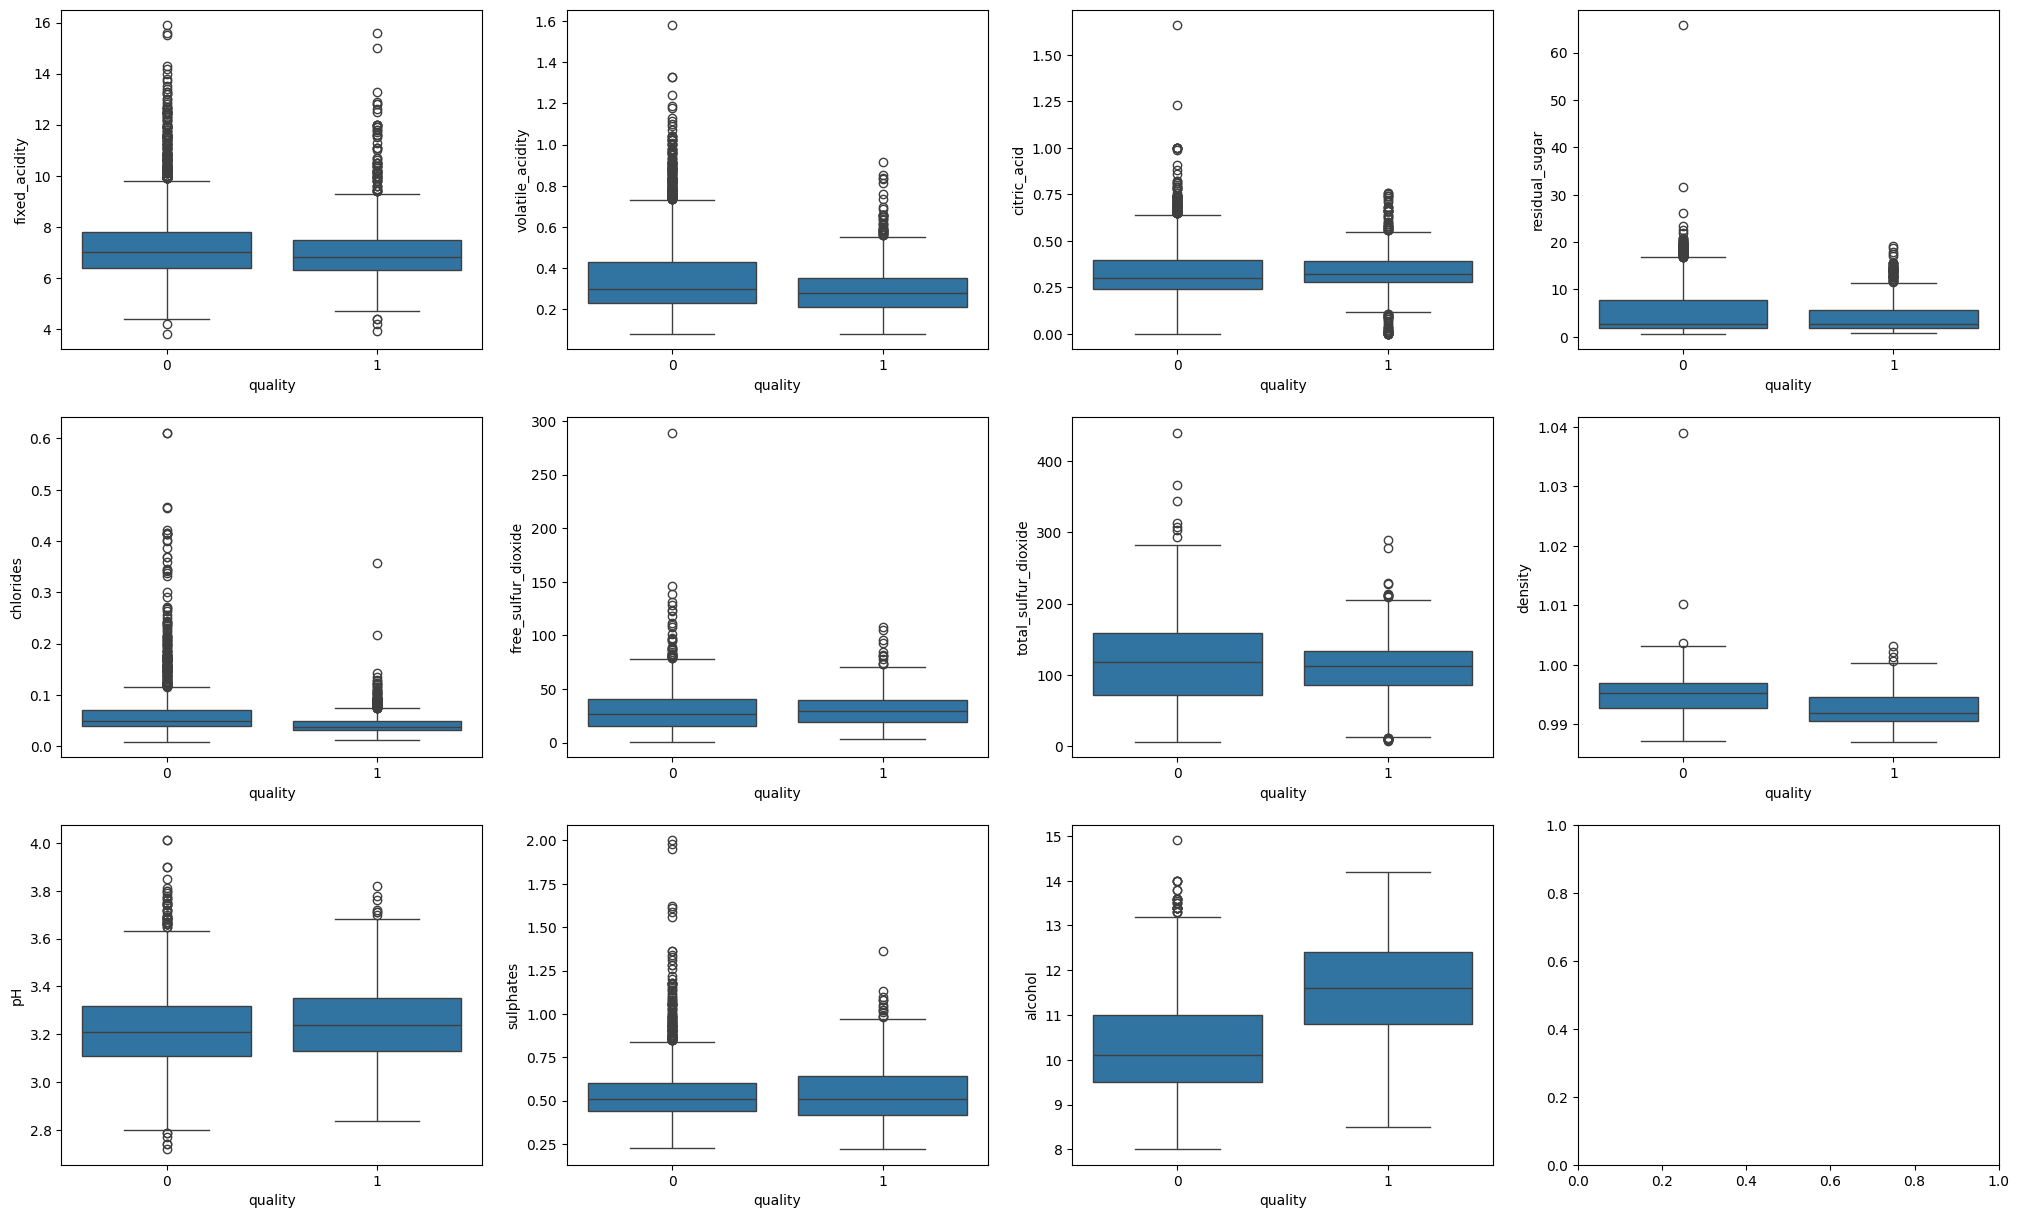

In [15]:
dims = (3, 4)
f, axes = plt.subplots(dims[0], dims[1], figsize=(25, 15))
axis_i, axis_j = 0, 0

for col in data.columns:
    if col == 'is_red' or col == 'quality':
        continue  # Box plots cannot be used on indicator variables
    sns.boxplot(x=high_quality, y=data[col], ax=axes[axis_i, axis_j])
    axis_j += 1
    if axis_j == dims[1]:
        axis_i += 1
        axis_j = 0

In [16]:
from sklearn.model_selection import train_test_split

X = data.drop(["quality"], axis=1)
y = data.quality

# Split out the training data
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)

# Split the remaining data equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)

In [17]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time

# Wrapper to return probability instead of class
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]


# Start MLflow experiment run
with mlflow.start_run(run_name='decision_tree_model'):

    model = DecisionTreeClassifier(
        max_depth=5,
        random_state=123
    )

    model.fit(X_train, y_train)

    # Predict probabilities for test set
    predictions_test = model.predict_proba(X_test)[:, 1]

    # Compute AUC score
    auc_score = roc_auc_score(y_test, predictions_test)

    # Log parameters and metrics
    mlflow.log_param("model_type", "DecisionTreeClassifier")
    mlflow.log_param("max_depth", 5)
    mlflow.log_metric("auc", auc_score)

    wrappedModel = SklearnModelWrapper(model)

    # Infer model signature
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))

    # Create conda environment for model deployment
    conda_env = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=[
            "cloudpickle=={}".format(cloudpickle.__version__),
            "scikit-learn=={}".format(sklearn.__version__)
        ],
        additional_conda_channels=None,
    )

    # Log the model
    mlflow.pyfunc.log_model(
        artifact_path="decision_tree_model",
        python_model=wrappedModel,
        conda_env=conda_env,
        signature=signature
    )

C:\Users\Aryan\anaconda3\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
C:\Users\Aryan\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.o

In [18]:
feature_importances = pd.DataFrame(model.feature_importances_, index=X_train.columns.tolist(), columns=['importance'])
feature_importances.sort_values('importance', ascending=False)

,importance
alcohol,0.630100
sulphates,0.093935
volatile_acidity,0.076182
residual_sugar,0.049411
citric_acid,0.043663
free_sulfur_dioxide,0.037386
chlorides,0.026826
pH,0.017762
fixed_acidity,0.012423
total_sulfur_dioxide,0.012311


In [19]:
run_id = mlflow.search_runs(
    filter_string='tags.mlflow.runName = "decision_tree_model"'
).iloc[0].run_id

model_name = "wine_quality"
model_version = mlflow.register_model(f"runs:/{run_id}/decision_tree_model", model_name)

time.sleep(15)

Registered model 'wine_quality' already exists. Creating a new version of this model...
2026/03/13 17:38:22 WARNING mlflow.tracking._model_registry.fluent: Run with id 02b425aabf1649aea5bfea3c08a5d561 has no artifacts at artifact path 'decision_tree_model', registering model based on models:/m-74cc16758da949af9e271b282c61c4a1 instead
Created version '2' of model 'wine_quality'.


In [29]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
client.transition_model_version_stage(
  name=model_name,
  version=model_version.version,
  stage="Production",
)

C:\Users\Aryan\AppData\Local\Temp\ipykernel_19716\3087969861.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1773374224666, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1773374243771, metrics=None, model_id=None, name='wine_quality', params=None, run_id='7f05583463494a57a7206f6efc64cee2', run_link=None, source='models:/m-ce648472306841f9893b065aef606a4d', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>

In [30]:
model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

# Sanity-check: This should match the AUC logged by MLflow
print(f'AUC: {roc_auc_score(y_test, model.predict(X_test))}')

AUC: 0.7994963359444993


In [23]:
import mlflow.pyfunc
import pandas as pd

# Load MLflow model
model = mlflow.pyfunc.load_model(f"models:/{model_name}/Production")

# Load dataset
new_data = pd.read_csv("winequality-red.csv", sep=";")

# Fix column names to match training schema
new_data.columns = new_data.columns.str.replace(" ", "_")

# Remove target column
new_data = new_data.drop(columns=["quality"], errors="ignore")

# Add wine type column expected by model
new_data["is_red"] = 1

# Ensure column order matches model schema
new_data = new_data[
    [
        "fixed_acidity",
        "volatile_acidity",
        "citric_acid",
        "residual_sugar",
        "chlorides",
        "free_sulfur_dioxide",
        "total_sulfur_dioxide",
        "density",
        "pH",
        "sulphates",
        "alcohol",
        "is_red",
    ]
]

# Make predictions
predictions = model.predict(new_data)

# Attach predictions
new_data["prediction"] = predictions

print(new_data.head())

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  is_red  prediction  
0      9.4       1    0.025575  
1      9.8       1  

In [27]:
type(predictions)

numpy.ndarray

In [29]:
import requests
import json

url = 'http://localhost:5001/invocations'  # Replace with the actual endpoint URL

data_dict = {"dataframe_split": X_test.to_dict(orient='split')}

response = requests.post(url, json=data_dict)
predictions = response.json()

print(predictions)

{'predictions': [0.02557544757033248, 0.18604651162790697, 0.02557544757033248, 0.027649769585253458, 0.027649769585253458, 0.24338624338624337, 0.537117903930131, 0.18604651162790697, 0.02557544757033248, 0.109375, 0.02557544757033248, 0.537117903930131, 0.02557544757033248, 0.027649769585253458, 0.24338624338624337, 0.027649769585253458, 0.02557544757033248, 0.02557544757033248, 0.28061224489795916, 0.537117903930131, 0.02557544757033248, 0.6888888888888889, 0.11594202898550725, 0.02557544757033248, 0.02557544757033248, 0.18604651162790697, 0.2643171806167401, 0.23404255319148937, 0.02557544757033248, 0.0546875, 0.0546875, 0.8461538461538461, 0.28061224489795916, 0.02557544757033248, 0.109375, 0.02557544757033248, 0.109375, 0.02557544757033248, 0.02557544757033248, 0.02557544757033248, 0.02557544757033248, 0.0546875, 0.11594202898550725, 0.537117903930131, 0.7926829268292683, 0.18604651162790697, 0.28061224489795916, 0.02557544757033248, 0.02557544757033248, 0.18604651162790697, 0.02